# 22 -- N=2, N=3, N=64: sledgehamr vs surrogate reconstruction

Compares the sledgehamr 3+1D ground truth against the 1+1D BubbleMaster
surrogate reconstruction (collision weights x the `gs1-*` production
runtime scans) for two, three, and sixty-four colliding bubbles, at
$\bar\lambda=0.84$ and $\bar\lambda=0.069$.

In [1]:
from pathlib import Path

import numpy as np
import h5py
import matplotlib.pyplot as plt
from matplotlib import rc, rcParams

import ptbuilder as pt
from ptbuilder.analysis import (
    load_scan, load_scan_manifest, load_weights, reconstruct_pair_spectrum,
    query_spectrum, to_chw, apply_keffsq,
)
from ptbuilder.sledgehamr import (
    load_output, get_gw_spectrum, get_spectrum_interpolated_at_time,
)
from ptbuilder.weight_scan_diagnostics import load_kinematics
from ptbuilder.ic import _cutoff_times

rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rcParams['text.usetex'] = True

REPO_ROOT   = Path(pt.__file__).parent.parent
DATA_DIR    = REPO_ROOT / 'data'
SH_RUNS_DIR = REPO_ROOT / 'sledgehamr_runs'
PLOTS_DIR   = REPO_ROOT / 'notebooks' / 'plots'
PLOTS_DIR.mkdir(exist_ok=True)

RECON_KR_MIN, RECON_KR_MAX = 1., 100.   # every scan's guaranteed kR_* coverage

## 1. N=2 / N=3 setup

Both pull from the same two 3-bubble sledgehamr realizations: N=2 takes
each of the 3 pairwise sub-collisions in isolation, N=3 is the full trio.

In [2]:
pos_084 = np.array([[72.25, 89.92, 100.],
                    [127.8, 89.92, 100.],
                    [108.7, 110.1, 100.]])
pos_069 = np.array([[16.23, 19.06, 22.5],
                    [28.77, 19.06, 22.5],
                    [24.08, 25.94, 22.5]])

CASES = {
    0.84: dict(
        positions=pos_084, L=200., zero_pad=2., n_weights=500, t_scan_max=70.,
        pairs=[
            dict(idx=(0, 1), sh_path=SH_RUNS_DIR / 'bubble_N3_234_0_1_',
                 weights_out=DATA_DIR / 'weights_out_N3_084_pair_0_1.h5'),
            dict(idx=(0, 2), sh_path=SH_RUNS_DIR / 'bubble_N3_234_0_2_',
                 weights_out=DATA_DIR / 'weights_out_N3_084_pair_0_2.h5'),
            dict(idx=(1, 2), sh_path=SH_RUNS_DIR / 'bubble_normalization_gamma2',
                 weights_out=DATA_DIR / 'weights_out_N3_084_pair_1_2.h5'),
        ],
        sh_path_3b=SH_RUNS_DIR / 'bubble_N3_234_0_1_2',
        weights_out_3b=DATA_DIR / 'weights_out_N3_084_3b.h5',
        scan_dir=DATA_DIR / 'runtime_scan_lb0.84_gs1-20_kR1-100_nw32',
        scan_loader=load_scan,
    ),
    0.069: dict(
        positions=pos_069, L=50., zero_pad=2., n_weights=500, t_scan_max=30.,
        pairs=[
            dict(idx=(0, 1), sh_path=SH_RUNS_DIR / 'bubble_N3_456_0_1_',
                 weights_out=DATA_DIR / 'weights_out_N3_069_pair_0_1.h5'),
            dict(idx=(0, 2), sh_path=SH_RUNS_DIR / 'bubble_N3_456_0_2_',
                 weights_out=DATA_DIR / 'weights_out_N3_069_pair_0_2.h5'),
            dict(idx=(1, 2), sh_path=SH_RUNS_DIR / 'bubble_N3_456_1_2_',
                 weights_out=DATA_DIR / 'weights_out_N3_069_pair_1_2.h5'),
        ],
        sh_path_3b=SH_RUNS_DIR / 'bubble_N3_456_0_1_2',
        weights_out_3b=DATA_DIR / 'weights_out_N3_069_3b.h5',
        scan_dir=DATA_DIR / 'runtime_scan_lb0.069_gs1-6_kR1-100_nw32',
        scan_loader=load_scan_manifest,
    ),
}

for lb, case in CASES.items():
    case['weights_times'] = np.linspace(1., case['t_scan_max'], case['n_weights'])
    L, pos = case['L'], case['positions']
    dists = []
    for i, j in [(0, 1), (0, 2), (1, 2)]:
        dp = pos[i] - pos[j]
        dp -= L * np.round(dp / L)
        dists.append(np.linalg.norm(dp))
    case['Rstar_3b'] = float(np.mean(dists))   # trio's own characteristic R_*
    case['scan'] = case['scan_loader'](case['scan_dir'])
    omega_min = case['scan'].rows[0].wlist[0]
    omega_max = max(r.wlist[-1] for r in case['scan'].rows)
    case['k_out'] = np.geomspace(omega_min, omega_max, 128)

Loaded scan runtime_scan_lb0.84_gs1-20_kR1-100_nw32: 124 rows, gamma_ij in [1.000, 50.000], T_MAX=388.362
Loaded scan runtime_scan_lb0.069_gs1-6_kR1-100_nw32: 36 rows, gamma_ij in [1.000, 15.000], T_MAX=17.552


In [3]:
pair_weights = {}   # (lb, idx) -> (n_weights,) weight array
pair_gamma   = {}   # (lb, idx) -> gamma (analytic, from weights output)
pair_d       = {}   # (lb, idx) -> centre-to-centre separation
pair_tm      = {}   # (lb, idx) -> BM comparison time t_m
trio_weights = {}   # lb -> dict(weights, pair_i, pair_j, gammas)
sh_output    = {}   # (lb, idx-or-'3b') -> pySledgehamr Output

for lb, case in CASES.items():
    n_wt = len(case['weights_times'])
    L, pos = case['L'], case['positions']

    for pair in case['pairs']:
        i, j = pair['idx']
        dp = pos[i] - pos[j]
        dp -= L * np.round(dp / L)
        d = float(np.linalg.norm(dp))
        t_m = float(_cutoff_times(d, 0, 1.)[2])

        w, pi, pj, gam = load_weights(pair['weights_out'], n_wt)
        pair_d[(lb, pair['idx'])]       = d
        pair_gamma[(lb, pair['idx'])]   = float(gam[0])
        pair_tm[(lb, pair['idx'])]      = t_m
        pair_weights[(lb, pair['idx'])] = w[0]
        sh_output[(lb, pair['idx'])]    = load_output(pair['sh_path'])

    w, pi, pj, gam = load_weights(case['weights_out_3b'], n_wt)
    trio_weights[lb] = dict(weights=w, pair_i=pi.astype(int), pair_j=pj.astype(int), gammas=gam)
    sh_output[(lb, '3b')] = load_output(case['sh_path_3b'])
    case['t_m_3b'] = max(pair_tm[(lb, p['idx'])] for p in case['pairs'])

Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 38
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 40
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 29
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxe

## 2. N=64 setup

In [4]:
bubbles64 = np.array([[  0.        ,   0.        ,   0.        ],
       [104.21080818, 134.00331875, 115.32260336],
       [ 82.91633086,  40.22040859, 161.10457444],
       [162.20889478, 164.79584079,   2.8384039 ],
       [154.47733984, 187.65793396,  20.16866321],
       [199.13096101,  27.01104231,  45.30013382],
       [168.5003722 ,  38.64441063,  52.81041635],
       [133.97360158,  91.59693268, 138.34643773],
       [ 50.28297449,  51.95537184,  23.62294384],
       [177.13769118, 134.66889799,   8.71668886],
       [ 30.68289591,   9.45788771,  50.50424856],
       [ 64.12769861, 195.12306707,  81.57164046],
       [ 56.68936652, 130.84497227, 108.2354709 ],
       [ 82.99174886, 121.03920058, 172.37415331],
       [127.09687502, 120.51398912, 134.53558472],
       [ 33.36926752,  13.63720659,   0.60996262],
       [ 18.39375397, 191.40492629, 122.47329764],
       [ 19.63641252,  63.09685344, 174.17147189],
       [ 90.74169878, 154.13735512, 104.39306946],
       [ 86.557716  ,  72.91515918, 182.95789915],
       [119.33310673,  37.76924713, 149.28485556],
       [ 17.13480987, 132.62322674, 189.63031283],
       [109.46636148, 118.08537517,  76.31000499],
       [170.09845239,   3.4854559 ,  23.50245978],
       [ 18.70476325, 147.66938079,  58.80734523],
       [111.64277024, 157.053698  , 132.24005744],
       [ 42.14101276,  50.93855746, 176.75407925],
       [ 14.51198083,  16.93867057,  60.2360491 ],
       [ 52.77856703,  29.30614115,  36.71599   ],
       [ 38.07656718,  13.10864189,  72.07363165],
       [138.51107657, 177.90126384, 114.77664924],
       [ 25.84809123, 112.82413992,  33.27661835],
       [  6.6733563 , 160.69190438, 139.70034561],
       [197.70475434,  13.8230847 ,  60.37034021],
       [ 12.25179549, 100.55314862,  78.92943814],
       [140.93499401, 164.76389065, 124.56483354],
       [100.40316917,  68.76075668,  17.56098047],
       [144.15542294,  50.57241845,  83.47993277],
       [ 43.42498771,  75.67311377, 122.44988237],
       [ 73.56937364,  38.65136447,   0.68298585],
       [160.40914341,   1.50148649,   2.225444  ],
       [127.8706212 ,  29.43082072,  23.094503  ],
       [ 10.24110325, 111.83791255, 156.45308871],
       [161.49404006, 163.38664412, 161.98093237],
       [ 27.04229405,  45.36589381, 117.35604037],
       [126.85079112, 162.26356355,  70.60492779],
       [128.66689612,  68.71766065, 150.35375572],
       [166.89624473, 124.99140447,  49.97804878],
       [ 22.58882999, 172.17683864,  41.74842148],
       [173.1491633 , 103.35193697,  79.45686904],
       [ 63.47467018, 157.89290094,  54.88476635],
       [ 83.264726  , 141.90140818, 151.48688241],
       [ 71.99367711,  16.40398225, 197.67281455],
       [ 55.41434491, 148.76063021,   3.30900276],
       [136.79240841,  60.8792625 , 193.43780416],
       [ 21.14423948,  15.16246438, 137.40606156],
       [ 37.08759453,  55.1292117 ,  75.06349727],
       [  6.48071698, 123.73465632,   4.00908165],
       [ 49.63963798,  63.59991319, 136.27840358],
       [  6.47400652, 161.05000329, 163.66077338],
       [142.56695796, 110.77450728, 194.29867779],
       [ 85.21456401,  72.43223496, 118.71280211],
       [103.95645911,   4.65524665, 154.29805374],
       [151.90410329, 147.74780743,  72.22549058]])

L64        = 200.
ZERO_PAD64 = 1.
Rstar64    = (L64**3 / len(bubbles64)) ** (1. / 3.)

w64, pi64, pj64, gam64 = load_weights(DATA_DIR / 'weights_out_N64.h5', n_t=1024)
weights_times64 = np.linspace(1., 70., 1024)
sh_out64 = load_output(SH_RUNS_DIR / 'bubbles_N64')
T1_64 = float(np.max(sh_out64.GetTimesOfGravitationalWaveSpectra()))
T2_64 = min(float(weights_times64[-1]), T1_64)

# lb=0.069: bubble positions from the Cutting-style placement file, weights
# already computed (mid-radius), sledgehamr run already computed. This
# case uses its own dedicated scan (finer time/gamma_ij resolution than
# gs1-6 above) -- its weights vanish well within that scan's shorter
# T_MAX, unlike the N=2/N=3 cases, which need gs1-6's longer T_MAX.
CUTTING_H5_069 = SH_RUNS_DIR / 'Cutting_lb0.069_N64_g4.00.h5'
with h5py.File(CUTTING_H5_069, 'r') as f:
    hdr069 = f['Header'][:]
    bubbles64_069 = np.column_stack([f['xlocs'][:], f['ylocs'][:], f['zlocs'][:]])
L64_069        = float(hdr069[1])
ZERO_PAD64_069 = 1.
Rstar64_069    = (L64_069 ** 3 / len(bubbles64_069)) ** (1. / 3.)

w64_069, pi64_069, pj64_069, gam64_069 = load_weights(
    DATA_DIR / 'weights_out_N64_lb069.h5', n_t=1024)
weights_times64_069 = np.linspace(1., 20., 1024)
sh_out64_069 = load_output(SH_RUNS_DIR / 'Cutting_lb0.069_N64_g4.00_leapfrog_2048_debug')
T1_069 = float(np.max(sh_out64_069.GetTimesOfGravitationalWaveSpectra()))
T2_069 = min(float(weights_times64_069[-1]), T1_069)

scan64_069 = load_scan_manifest(DATA_DIR / 'runtime_scan_lb0.069_finer_gs1-4_kR1-100_nw32')
omega_min_069 = scan64_069.rows[0].wlist[0]
omega_max_069 = max(r.wlist[-1] for r in scan64_069.rows)
k_out64_069 = np.geomspace(omega_min_069, omega_max_069, 128)

Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 46
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0
Number of slices found: 0
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 0
Number of spectra found: 0
Number of gravitational wave spectra found: 57
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0


Loaded scan runtime_scan_lb0.069_finer_gs1-4_kR1-100_nw32: 46 rows, gamma_ij in [1.000, 10.000], T_MAX=12.486


## 3. Reconstructions

In [5]:
# N=2: single-point query at (gamma, t_m) per pair -- a genuine two-bubble
# collision has no third body to occlude it, so the reconstructed spectrum
# is just the scan's own cumulative value at t_m. y is converted to the
# CHW dimensionless quantity using each pair's own d as its R_*.
n2_results = {}   # (lb, idx) -> dict(kR_recon, y_recon, kR_sh, y_sh, yerr_sh)
for lb, case in CASES.items():
    scan = case['scan']
    for pair in case['pairs']:
        key = (lb, pair['idx'])
        d, gamma, t_m = pair_d[key], pair_gamma[key], pair_tm[key]

        k, s, _ = query_spectrum(scan, gamma, t_m, no_throw=True)
        y_recon = to_chw(np.interp(case['k_out'], k, s, left=0., right=0.),
                         d, lb, (case['L'] * case['zero_pad']) ** 3)
        kR_recon = case['k_out'] * d
        valid = (kR_recon >= RECON_KR_MIN) & (kR_recon <= RECON_KR_MAX)
        kR_recon, y_recon = kR_recon[valid], y_recon[valid]

        k_sh, y_sh, t_act = get_spectrum_interpolated_at_time(
            sh_output[key], t_m, case['L'], case['zero_pad'])
        k_sh, y_sh = k_sh[1:], y_sh[1:]   # drop the k=0 mode
        r_sh = k_sh * (case['L'] * case['zero_pad']) / (2 * np.pi)
        n_modes = np.maximum(1., 4 * np.pi * r_sh ** 2)
        yerr_sh = y_sh * np.sqrt(2. / n_modes)
        y_sh, yerr_sh = to_chw(y_sh, d, lb, (case['L'] * case['zero_pad']) ** 3), \
                       to_chw(yerr_sh, d, lb, (case['L'] * case['zero_pad']) ** 3)

        n2_results[key] = dict(kR_recon=kR_recon, y_recon=y_recon,
                               kR_sh=k_sh * d, y_sh=y_sh, yerr_sh=yerr_sh)

In [6]:
# N=3: trio-combined reconstruction (weights x scan, summed over the 3
# pairs). y converted to CHW units using the trio's own mean-separation R*.
n3_results = {}   # lb -> dict(kR_recon, y_recon, kR_sh, y_sh, yerr_sh)
for lb, case in CASES.items():
    wd = trio_weights[lb]
    scan, k_out, Rstar_3b = case['scan'], case['k_out'], case['Rstar_3b']
    Leff = case['L'] * case['zero_pad']

    combined = np.zeros(len(k_out))
    for c_idx in range(len(wd['pair_i'])):
        combined += reconstruct_pair_spectrum(
            float(wd['gammas'][c_idx]), wd['weights'][c_idx], case['weights_times'],
            case['t_m_3b'], scan, k_out)
    combined = to_chw(combined, Rstar_3b, lb, Leff ** 3)

    kR_recon = k_out * Rstar_3b
    valid = (kR_recon >= RECON_KR_MIN) & (kR_recon <= RECON_KR_MAX)
    kR_recon, combined = kR_recon[valid], combined[valid]

    k_sh, y_sh, t_act = get_spectrum_interpolated_at_time(
        sh_output[(lb, '3b')], case['t_m_3b'], case['L'], case['zero_pad'])
    k_sh, y_sh = k_sh[1:], y_sh[1:]
    r_sh = k_sh * Leff / (2 * np.pi)
    n_modes = np.maximum(1., 4 * np.pi * r_sh ** 2)
    yerr_sh = y_sh * np.sqrt(2. / n_modes)
    y_sh, yerr_sh = to_chw(y_sh, Rstar_3b, lb, Leff ** 3), to_chw(yerr_sh, Rstar_3b, lb, Leff ** 3)

    n3_results[lb] = dict(kR_recon=kR_recon, y_recon=combined,
                          kR_sh=k_sh * Rstar_3b, y_sh=y_sh, yerr_sh=yerr_sh)

In [7]:
# N=64: trio-style reconstruction summed over all colliding pairs, per lb --
# sledgehamr late-time band (median + range from T_COLL_END to the last
# snapshot). The min/max half-widths are temporal variability (ringing
# during the late-time oscillation phase), not a statistical uncertainty;
# they widen at high k because the high-k tail sits closest to the
# numerical noise floor, so the same absolute ringing amplitude is a much
# larger relative swing there. The mode-counting statistical error
# (sqrt(2/N_modes), same as the N=2/N=3 bands) is added to each half-width
# in quadrature as an independent additional source of uncertainty.

def late_time_band(pi, w, gam, weights_times, sh_out, scan, k_out, Rstar, L, zero_pad, lb, t_max):
    Leff = L * zero_pad
    recon = np.zeros(len(k_out))
    for p in range(len(pi)):
        recon += reconstruct_pair_spectrum(float(gam[p]), w[p], weights_times, t_max,
                                           scan, k_out)
    recon = to_chw(recon, Rstar, lb, Leff ** 3)
    kR_recon = k_out * Rstar
    valid = (kR_recon >= RECON_KR_MIN) & (kR_recon <= RECON_KR_MAX)
    kR_recon, recon = kR_recon[valid], recon[valid]

    sum_w = w.sum(axis=0)
    active = np.where(sum_w > 0.01)[0]
    t_coll_end = float(weights_times[active[-1]])
    times = np.array(sh_out.GetTimesOfGravitationalWaveSpectra())
    late_idx = np.where(times >= t_coll_end)[0]

    k_ref, spec_ref, _ = get_gw_spectrum(sh_out, int(late_idx[-1]), L, zero_pad)
    k_ref, spec_ref = k_ref[1:], spec_ref[1:]
    late_3d = []
    for idx in late_idx:
        k_late, y_late, _ = get_gw_spectrum(sh_out, int(idx), L, zero_pad)
        k_late, y_late = k_late[1:], y_late[1:]
        late_3d.append(np.interp(k_ref, k_late, y_late, left=np.nan, right=np.nan))
    late_3d = np.asarray(late_3d)
    late_median = to_chw(np.nanmedian(late_3d, axis=0), Rstar, lb, Leff ** 3)
    late_min    = to_chw(np.nanmin(late_3d, axis=0), Rstar, lb, Leff ** 3)
    late_max    = to_chw(np.nanmax(late_3d, axis=0), Rstar, lb, Leff ** 3)

    r_ref = k_ref * Leff / (2 * np.pi)
    n_modes = np.maximum(1., 4 * np.pi * r_ref ** 2)
    sigma_modes = late_median * np.sqrt(2. / n_modes)
    late_min = late_median - np.sqrt((late_median - late_min) ** 2 + sigma_modes ** 2)
    late_max = late_median + np.sqrt((late_max - late_median) ** 2 + sigma_modes ** 2)

    return dict(kR_recon=kR_recon, y_recon=recon, kR_sh=k_ref * Rstar,
               y_median=late_median, y_min=late_min, y_max=late_max,
               t_range=(times[late_idx[0]], times[late_idx[-1]]))


n64_results = {
    0.84: late_time_band(pi64, w64, gam64, weights_times64, sh_out64, CASES[0.84]['scan'],
                         CASES[0.84]['k_out'], Rstar64, L64, ZERO_PAD64, 0.84, T2_64),
    0.069: late_time_band(pi64_069, w64_069, gam64_069, weights_times64_069, sh_out64_069,
                          scan64_069, k_out64_069, Rstar64_069, L64_069, ZERO_PAD64_069,
                          0.069, T2_069),
}

## 4. Figure

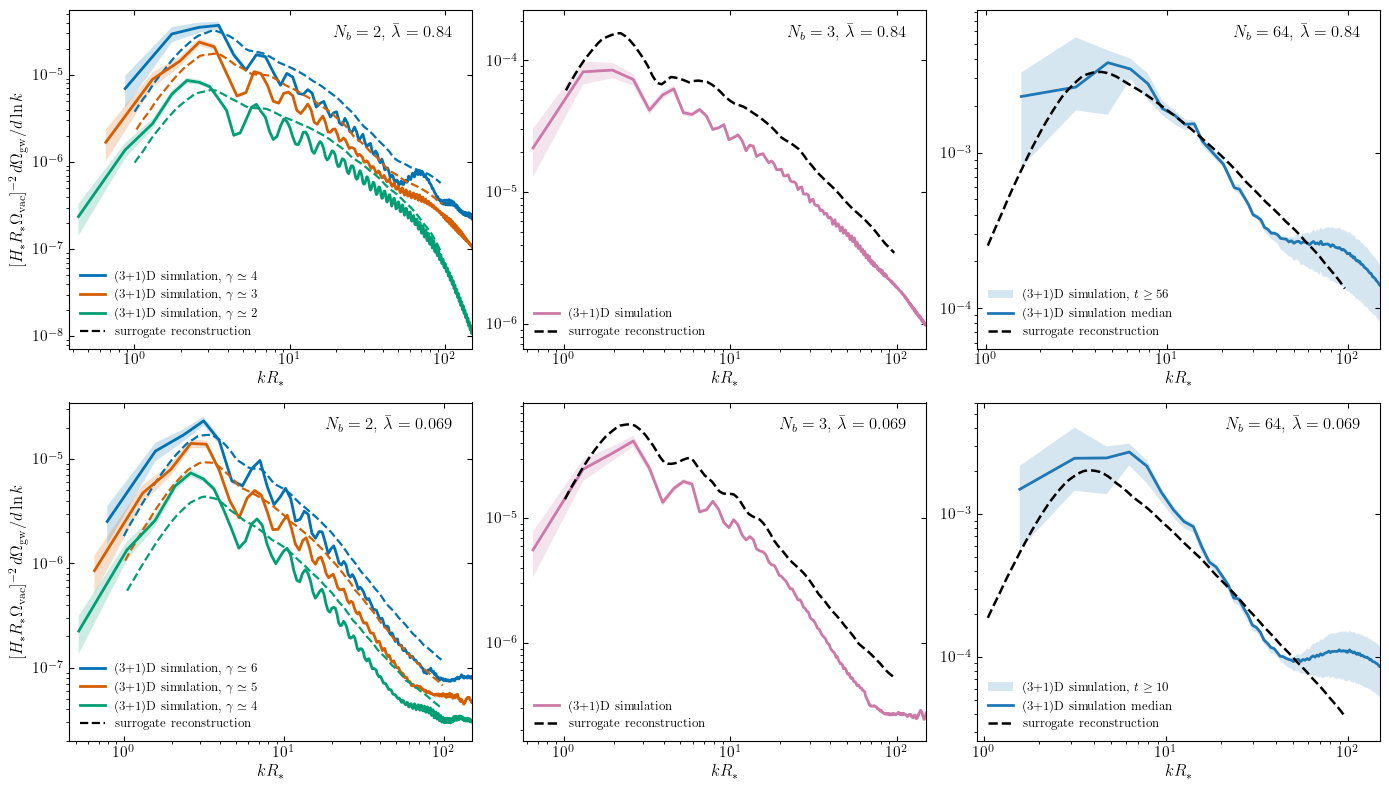

In [8]:
colors_pair = ['#0072B2', '#D55E00', '#009E73']
color_3b    = '#CC79A7'
color_64    = 'C0'
RECON_COLOR = 'black'
X_MAX = 150.


def visible_extent(*xy_pairs, x_min=None, x_max=X_MAX):
    ys, xmins = [], []
    for x, y in xy_pairs:
        mask = x <= x_max
        if x_min is not None:
            mask &= x >= x_min
        if mask.any():
            ys.append(y[mask])
            xmins.append(x[mask].min())
    ys = np.concatenate(ys)
    ys = ys[ys > 0]
    return min(xmins), ys.min(), ys.max()


def style_panel(ax, x_min, ymin, ymax, title):
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(x_min / 1.15, X_MAX)
    ax.set_ylim(ymin / 1.5, ymax * 1.5)
    ax.set_xlabel(r'$kR_*$', fontsize=12)
    ax.text(0.95, 0.96, title, transform=ax.transAxes, ha='right', va='top', fontsize=12)
    ax.legend(frameon=False, fontsize=9, loc='lower left')
    ax.tick_params(axis='both', labelsize=11, top=True, right=True, direction='in')


fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for row_idx, lb in enumerate([0.84, 0.069]):
    case = CASES[lb]

    ax = axes[row_idx, 0]
    extents = []
    for pair, color in zip(case['pairs'], colors_pair):
        r = n2_results[(lb, pair['idx'])]
        gamma = pair_gamma[(lb, pair['idx'])]
        ax.plot(r['kR_sh'], r['y_sh'], color=color, lw=2,
                label=rf'(3+1)D simulation, $\gamma\simeq{round(gamma)}$')
        ax.fill_between(r['kR_sh'], np.maximum(r['y_sh'] - r['yerr_sh'], 1e-300),
                        r['y_sh'] + r['yerr_sh'], color=color, alpha=0.2, linewidth=0)
        ax.plot(r['kR_recon'], r['y_recon'], color=color, lw=1.6, ls='--')
        extents.append(visible_extent((r['kR_sh'], r['y_sh']), (r['kR_recon'], r['y_recon'])))
    ax.plot([], [], color=RECON_COLOR, lw=1.6, ls='--', label='surrogate reconstruction')
    x_min = min(e[0] for e in extents)
    style_panel(ax, x_min, min(e[1] for e in extents), max(e[2] for e in extents),
               rf'$N_b=2$,  $\bar\lambda={lb}$')

    ax = axes[row_idx, 1]
    r3 = n3_results[lb]
    ax.plot(r3['kR_sh'], r3['y_sh'], color=color_3b, lw=2, label='(3+1)D simulation')
    ax.fill_between(r3['kR_sh'], np.maximum(r3['y_sh'] - r3['yerr_sh'], 1e-300),
                    r3['y_sh'] + r3['yerr_sh'], color=color_3b, alpha=0.2, linewidth=0)
    ax.plot(r3['kR_recon'], r3['y_recon'], color=RECON_COLOR, lw=1.8, ls='--',
            label='surrogate reconstruction')
    x_min, ymin, ymax = visible_extent((r3['kR_sh'], r3['y_sh']), (r3['kR_recon'], r3['y_recon']))
    style_panel(ax, x_min, ymin, ymax, rf'$N_b=3$,  $\bar\lambda={lb}$')

    ax = axes[row_idx, 2]
    r64 = n64_results[lb]
    ax.fill_between(r64['kR_sh'], r64['y_min'], r64['y_max'],
                    color=color_64, alpha=0.18, linewidth=0,
                    label=rf'(3+1)D simulation, $t\geq{r64["t_range"][0]:.0f}$')
    ax.plot(r64['kR_sh'], r64['y_median'], color=color_64, lw=2,
            label='(3+1)D simulation median')
    ax.plot(r64['kR_recon'], r64['y_recon'], color=RECON_COLOR,
            lw=1.8, ls='--', label='surrogate reconstruction')
    x_min, ymin, ymax = visible_extent((r64['kR_sh'], r64['y_min']),
                                       (r64['kR_sh'], r64['y_max']),
                                       (r64['kR_recon'], r64['y_recon']))
    style_panel(ax, x_min, ymin, ymax, rf'$N_b=64$,  $\bar\lambda={lb}$')

ylabel = r'$[H_*R_*\Omega_{\rm vac}]^{-2}\,d\Omega_{\rm gw}/d\ln k$'
axes[0, 0].set_ylabel(ylabel, fontsize=12)
axes[1, 0].set_ylabel(ylabel, fontsize=12)

fig.tight_layout()
fig.savefig(PLOTS_DIR / 'n2n3n64_surrogate_grid.pdf', bbox_inches='tight')
plt.show()